# Historical Timetable Sample

This notebook uses the project CLI in two explicit stages: `fetch` downloads raw timetable data, and `preprocess` turns it into a clean table. Timetable `assemble` is intentionally left for later.

In [1]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import pandas as pd


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root.")


REPO_ROOT = find_repo_root()
CLI = REPO_ROOT / "src" / "cli.py"


def run_cli(*args: str) -> dict:
    result = subprocess.run(
        [sys.executable, str(CLI), *args],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    )
    return json.loads(result.stdout)

In [2]:
SAMPLE_START = "2026-06-26T00:00:00+02:00"
SAMPLE_END = "2026-06-26T06:00:00+02:00"
CHUNK_SIZE = "2h"
REQUEST_LIMIT = 50000
FILTERS = {
    "location_signature": None,
    "advertised_train_ident": None,
    "activity_type": None,
    "operator": None,
    "canceled": None,
}

print({
    "sample_start": SAMPLE_START,
    "sample_end": SAMPLE_END,
    "chunk_size": CHUNK_SIZE,
    "request_limit": REQUEST_LIMIT,
    "filters": FILTERS,
})

{'sample_start': '2026-06-26T00:00:00+02:00', 'sample_end': '2026-06-26T06:00:00+02:00', 'chunk_size': '2h', 'request_limit': 50000, 'filters': {'location_signature': None, 'advertised_train_ident': None, 'activity_type': None, 'operator': None, 'canceled': None}}


In [3]:
fetch_args = [
    "data",
    "timetable",
    "fetch",
    "--start",
    SAMPLE_START,
    "--end",
    SAMPLE_END,
    "--chunk-size",
    CHUNK_SIZE,
    "--limit",
    str(REQUEST_LIMIT),
]
for key, value in FILTERS.items():
    if value is not None:
        fetch_args.extend([f"--{key.replace('_', '-')}", str(value)])

fetch_result = run_cli(*fetch_args)
fetch_result

{'domain': 'timetable',
 'stage': 'fetch',
 'raw_path': '/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/timetable/raw/train_announcements_sample.json',
 'num_payloads': 3,
 'filters': {'location_signature': None,
  'advertised_train_ident': None,
  'activity_type': None,
  'operator': None,
  'canceled': None},
 'chunk_log': [{'chunk_start': '2026-06-26 00:00:00+02:00',
   'chunk_end': '2026-06-26 02:00:00+02:00',
   'records': 527,
   'truncated': False},
  {'chunk_start': '2026-06-26 02:00:00+02:00',
   'chunk_end': '2026-06-26 04:00:00+02:00',
   'records': 77,
   'truncated': False},
  {'chunk_start': '2026-06-26 04:00:00+02:00',
   'chunk_end': '2026-06-26 06:00:00+02:00',
   'records': 2947,
   'truncated': False}]}

In [4]:
preprocess_args = [
    "data",
    "timetable",
    "preprocess",
]
for key, value in FILTERS.items():
    if value is not None:
        preprocess_args.extend([f"--{key.replace('_', '-')}", str(value)])

preprocess_result = run_cli(*preprocess_args)
preprocess_result

{'domain': 'timetable',
 'stage': 'preprocess',
 'rows': 3551,
 'columns': ['ActivityId',
  'LocationSignature',
  'AdvertisedTrainIdent',
  'OperationalTrainNumber',
  'ActivityType',
  'AdvertisedTimeAtLocation',
  'EstimatedTimeAtLocation',
  'TimeAtLocation',
  'estimated_delay_minutes',
  'actual_delay_minutes',
  'TrackAtLocation',
  'FromLocation',
  'ViaFromLocation',
  'ToLocation',
  'ViaToLocation',
  'Operator',
  'InformationOwner',
  'ProductInformation',
  'TypeOfTraffic',
  'Deviation',
  'Canceled',
  'WebLink',
  'WebLinkName',
  'Advertised',
  'Deleted',
  'DepartureDateOTN',
  'EstimatedTimeIsPreliminary',
  'ModifiedTime',
  'NewEquipment',
  'PlannedEstimatedTimeAtLocationIsValid',
  'ScheduledDepartureDateTime',
  'is_departure',
  'is_arrival',
  'service_date',
  'service_hour'],
 'filters': {'location_signature': None,
  'advertised_train_ident': None,
  'activity_type': None,
  'operator': None,
  'canceled': None},
 'saved': {'csv': '/Users/felixschulz/Libr

In [5]:
chunk_log = pd.DataFrame(fetch_result["chunk_log"])
df = pd.read_csv(REPO_ROOT / preprocess_result["saved"]["csv"])
chunk_log

,chunk_start,chunk_end,records,truncated
0,2026-06-26 00:00:00+02:00,2026-06-26 02:00:00+02:00,527,False
1,2026-06-26 02:00:00+02:00,2026-06-26 04:00:00+02:00,77,False
2,2026-06-26 04:00:00+02:00,2026-06-26 06:00:00+02:00,2947,False


In [17]:
df.columns

Index(['ActivityId', 'LocationSignature', 'AdvertisedTrainIdent',
       'OperationalTrainNumber', 'ActivityType', 'AdvertisedTimeAtLocation',
       'EstimatedTimeAtLocation', 'TimeAtLocation', 'estimated_delay_minutes',
       'actual_delay_minutes', 'TrackAtLocation', 'FromLocation',
       'ViaFromLocation', 'ToLocation', 'ViaToLocation', 'Operator',
       'InformationOwner', 'ProductInformation', 'TypeOfTraffic', 'Deviation',
       'Canceled', 'WebLink', 'WebLinkName', 'Advertised', 'Deleted',
       'DepartureDateOTN', 'EstimatedTimeIsPreliminary', 'ModifiedTime',
       'NewEquipment', 'PlannedEstimatedTimeAtLocationIsValid',
       'ScheduledDepartureDateTime', 'is_departure', 'is_arrival',
       'service_date', 'service_hour'],
      dtype='str')

<Axes: title={'center': 'Actual Delay Distribution (minutes)'}, xlabel='actual_delay_minutes'>

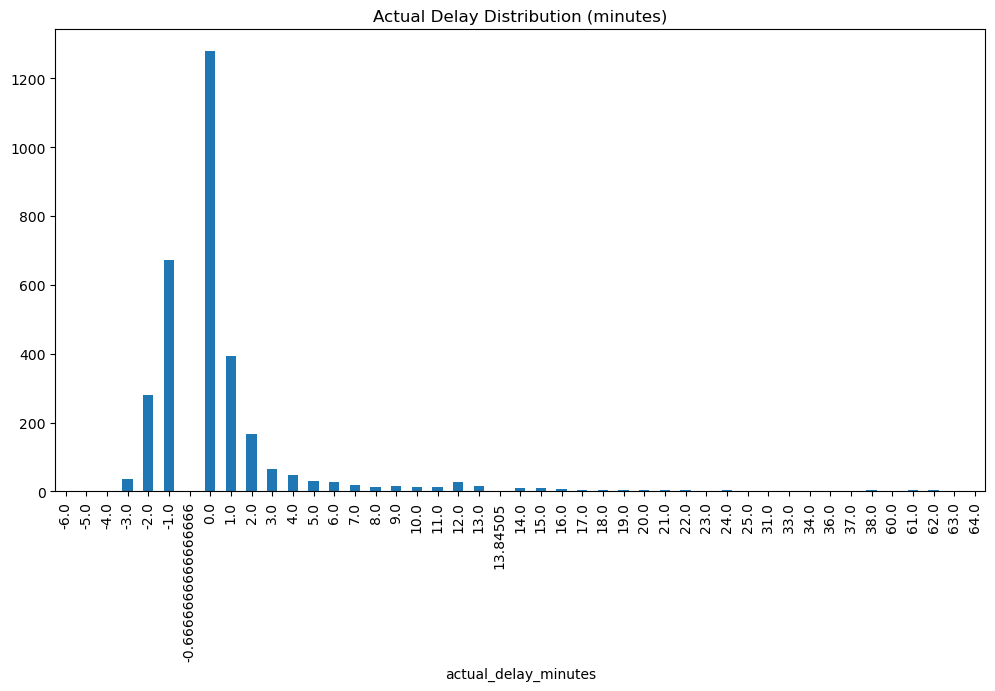

In [23]:
df.actual_delay_minutes.value_counts().sort_index().plot.bar(figsize=(12, 6), title="Actual Delay Distribution (minutes)")

In [21]:
df.ProductInformation.value_counts()

ProductInformation
[{"Code": "PNA020", "Description": "Pågatågen"}]                                                808
[{"Code": "PNA054", "Description": "SL Pendeltåg"}, {"Code": "PNA091", "Description": "43"}]    450
[{"Code": "PNA040", "Description": "Västtågen"}]                                                384
[{"Code": "PNA044", "Description": "Öresundståg"}]                                              275
[{"Code": "PNA054", "Description": "SL Pendeltåg"}, {"Code": "PNA086", "Description": "40"}]    263
[{"Code": "PNA054", "Description": "SL Pendeltåg"}, {"Code": "PNA088", "Description": "41"}]    260
[{"Code": "PNA014", "Description": "Mälartåg"}]                                                 229
[{"Code": "PNA041", "Description": "Västtågen"}]                                                226
[{"Code": "PNA021", "Description": "TiB"}]                                                      132
[{"Code": "PNA010", "Description": "Krösatågen"}]                                

In [18]:
df.Canceled.value_counts()

Canceled
False    3469
True       82
Name: count, dtype: int64

In [16]:
df[df.AdvertisedTimeAtLocation.astype("datetime64[s, UTC]").dt.hour.between(0, 2)].head(10)

,ActivityId,LocationSignature,AdvertisedTrainIdent,OperationalTrainNumber,ActivityType,AdvertisedTimeAtLocation,EstimatedTimeAtLocation,TimeAtLocation,estimated_delay_minutes,actual_delay_minutes,...,DepartureDateOTN,EstimatedTimeIsPreliminary,ModifiedTime,NewEquipment,PlannedEstimatedTimeAtLocationIsValid,ScheduledDepartureDateTime,is_departure,is_arrival,service_date,service_hour
527,1500adde-8c5d-8dca-08de-c7e6b7b1fa1a,Lu,11245,11245.0,Ankomst,2026-06-26 00:01:00+00:00,2026-06-26 00:11:00+00:00,2026-06-26 00:12:00+00:00,10.0,11.0,...,2026-06-25 22:00:00+00:00,False,2026-06-26 00:12:08.832000+00:00,0.0,False,2026-06-25 22:00:00+00:00,False,True,2026-06-26,0
528,1500adde-8c5d-8dca-08de-c7e6b7b1fa1b,Lu,11245,11245.0,Avgang,2026-06-26 00:01:00+00:00,2026-06-26 00:11:00+00:00,2026-06-26 00:14:00+00:00,10.0,13.0,...,2026-06-25 22:00:00+00:00,False,2026-06-26 00:14:22.730000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-26,0
529,1500adde-8c5d-8dca-08de-c7e76f5ab102,Maa,8480,8480.0,Ankomst,2026-06-26 00:01:00+00:00,NaN,2026-06-25 23:59:00+00:00,NaN,-2.0,...,2026-06-25 22:00:00+00:00,False,2026-06-25 23:59:12.958000+00:00,0.0,False,2026-06-25 22:00:00+00:00,False,True,2026-06-26,0
530,1500adde-8c5d-8dca-08de-c7e76f5ab103,Maa,8480,8480.0,Avgang,2026-06-26 00:01:00+00:00,NaN,2026-06-26 00:02:00+00:00,NaN,1.0,...,2026-06-25 22:00:00+00:00,False,2026-06-26 00:02:53.882000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-26,0
531,1500adde-8c5d-8dca-08de-c7e6bb7018f3,Hbgb,11843,11843.0,Ankomst,2026-06-26 00:02:00+00:00,2026-06-26 00:04:00+00:00,2026-06-26 00:04:00+00:00,2.0,2.0,...,2026-06-25 22:00:00+00:00,False,2026-06-26 00:04:10.613000+00:00,0.0,False,2026-06-25 22:00:00+00:00,False,True,2026-06-26,0
532,1500adde-8c5d-8dca-08de-c7e6bb7018f4,Hbgb,11843,11843.0,Avgang,2026-06-26 00:02:00+00:00,2026-06-26 00:04:00+00:00,2026-06-26 00:04:00+00:00,2.0,2.0,...,2026-06-25 22:00:00+00:00,False,2026-06-26 00:05:20.061000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-26,0
533,1500adde-8c5d-8dca-08de-c7e6b7b1fa1c,Kgå,11245,11245.0,Ankomst,2026-06-26 00:03:00+00:00,2026-06-26 00:15:00+00:00,2026-06-26 00:15:00+00:00,12.0,12.0,...,2026-06-25 22:00:00+00:00,False,2026-06-26 00:15:48.269000+00:00,0.0,False,2026-06-25 22:00:00+00:00,False,True,2026-06-26,0
534,1500adde-8c5d-8dca-08de-c7e6b7b1fa1d,Kgå,11245,11245.0,Avgang,2026-06-26 00:03:00+00:00,2026-06-26 00:15:00+00:00,2026-06-26 00:16:00+00:00,12.0,13.0,...,2026-06-25 22:00:00+00:00,False,2026-06-26 00:17:19.987000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-26,0
535,1500adde-8c5d-8dca-08de-c7e6b7b1fa1e,Hjp,11245,11245.0,Ankomst,2026-06-26 00:06:00+00:00,2026-06-26 00:18:00+00:00,2026-06-26 00:18:00+00:00,12.0,12.0,...,2026-06-25 22:00:00+00:00,False,2026-06-26 00:18:45.276000+00:00,0.0,False,2026-06-25 22:00:00+00:00,False,True,2026-06-26,0
536,1500adde-8c5d-8dca-08de-c7e6b7b1fa1f,Hjp,11245,11245.0,Avgang,2026-06-26 00:06:00+00:00,2026-06-26 00:18:00+00:00,2026-06-26 00:20:00+00:00,12.0,14.0,...,2026-06-25 22:00:00+00:00,False,2026-06-26 00:20:19.306000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-26,0


In [10]:
df.TypeOfTraffic.unique()

<ArrowStringArray>
['[{"Code": "YNA004", "Description": "Pendeltåg"}]',
      '[{"Code": "YNA002", "Description": "Buss"}]',
       '[{"Code": "YNA001", "Description": "Tåg"}]',
                                                nan]
Length: 4, dtype: str

In [6]:
df.head(10)

,ActivityId,LocationSignature,AdvertisedTrainIdent,OperationalTrainNumber,ActivityType,AdvertisedTimeAtLocation,EstimatedTimeAtLocation,TimeAtLocation,estimated_delay_minutes,actual_delay_minutes,...,DepartureDateOTN,EstimatedTimeIsPreliminary,ModifiedTime,NewEquipment,PlannedEstimatedTimeAtLocationIsValid,ScheduledDepartureDateTime,is_departure,is_arrival,service_date,service_hour
0,1500adde-8c5d-8dca-08de-c7e73a9fc9e2,Mr,2983,2983.0,Avgang,2026-06-25 22:00:00+00:00,NaN,NaN,NaN,NaN,...,2026-06-25 22:00:00+00:00,False,2026-06-24 12:16:46.068000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-25,22
1,1500adde-8c5d-8dca-08de-c74dc66e4176,Yb,73791,NaN,Avgang,2026-06-25 22:02:00+00:00,NaN,NaN,NaN,NaN,...,0000-12-31 23:00:00+00:00,False,2026-06-11 00:11:28.526000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-25,22
2,1500adde-8c5d-8dca-08de-c7e71053abd5,Söc,2477,2477.0,Avgang,2026-06-25 22:03:00+00:00,NaN,2026-06-25 22:03:00+00:00,NaN,0.0,...,2026-06-25 22:00:00+00:00,False,2026-06-26 00:11:12.692000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-25,22
3,1500adde-8c5d-8dca-08de-c7e6c23ba0c1,Cr,1243,1243.0,Avgang,2026-06-25 22:04:00+00:00,2026-06-25 22:14:00+00:00,2026-06-25 22:13:00+00:00,10.0,9.0,...,2026-06-25 22:00:00+00:00,True,2026-06-26 00:11:12.723000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-25,22
4,1500adde-8c5d-8dca-08de-c7e73a9fc9e3,Rs,2983,2983.0,Ankomst,2026-06-25 22:04:00+00:00,NaN,NaN,NaN,NaN,...,2026-06-25 22:00:00+00:00,False,2026-06-24 12:16:46.068000+00:00,0.0,False,2026-06-25 22:00:00+00:00,False,True,2026-06-25,22
5,1500adde-8c5d-8dca-08de-c7e73aa22c74,Rs,2983,2983.0,Avgang,2026-06-25 22:04:00+00:00,NaN,NaN,NaN,NaN,...,2026-06-25 22:00:00+00:00,False,2026-06-24 12:16:46.084000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-25,22
6,1500adde-8c5d-8dca-08de-c7e75ed3559c,Arnn,7879,7879.0,Avgang,2026-06-25 22:05:00+00:00,NaN,2026-06-25 22:05:00+00:00,NaN,0.0,...,2026-06-25 22:00:00+00:00,False,2026-06-25 22:05:55.288000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-25,22
7,1500adde-8c5d-8dca-08de-c7e75ecddfd6,Cst,7878,7878.0,Avgang,2026-06-25 22:05:00+00:00,NaN,2026-06-25 22:04:00+00:00,NaN,-1.0,...,2026-06-25 22:00:00+00:00,False,2026-06-25 22:05:36.645000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-25,22
8,1500adde-8c5d-8dca-08de-c74dc56b3a1f,G,63500,NaN,Avgang,2026-06-25 22:05:00+00:00,NaN,NaN,NaN,NaN,...,0000-12-31 23:00:00+00:00,False,2026-06-11 00:10:41.180000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-25,22
9,1500adde-8c5d-8dca-08de-c7e73a8f1953,Söc,2982,2982.0,Avgang,2026-06-25 22:06:00+00:00,NaN,2026-06-25 22:06:00+00:00,NaN,0.0,...,2026-06-25 22:00:00+00:00,False,2026-06-25 22:06:36.763000+00:00,0.0,False,2026-06-25 22:00:00+00:00,True,False,2026-06-25,22
